In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Dataset .csv")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9551
Number of columns: 21


In [5]:
print(df.columns.tolist())

['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [6]:
df["Cuisines"].head(10)

,Cuisines
0,"French, Japanese, Desserts"
1,Japanese
2,"Seafood, Asian, Filipino, Indian"
3,"Japanese, Sushi"
4,"Japanese, Korean"
5,Chinese
6,"Asian, European"
7,"Seafood, Filipino, Asian, European"
8,"European, Asian, Indian"
9,Filipino


In [7]:
print("Missing values in Cuisines:", df["Cuisines"].isnull().sum())

Missing values in Cuisines: 9


In [8]:
cuisine_counts = (
    df["Cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

top_3 = cuisine_counts.head(3)

top_3

,count
Cuisines,
North Indian,3960
Chinese,2735
Fast Food,1986


In [9]:
percentage = (top_3 / len(df)) * 100

percentage.round(2)

,count
Cuisines,
North Indian,41.46
Chinese,28.64
Fast Food,20.79


In [10]:
result = pd.DataFrame({
    "Cuisine": top_3.index,
    "Number of Restaurants": top_3.values,
    "Percentage": percentage.round(2).values
})

result

,Cuisine,Number of Restaurants,Percentage
0,North Indian,3960,41.46
1,Chinese,2735,28.64
2,Fast Food,1986,20.79


In [11]:
city_counts = df["City"].value_counts()

city_counts.head(10)

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Lucknow,21
Ahmedabad,21
Amritsar,21


In [12]:
city_counts.head(1)

,count
City,
New Delhi,5473


In [13]:
city_avg_rating = df.groupby("City")["Aggregate rating"].mean()

city_avg_rating.round(2)

,Aggregate rating
City,
Abu Dhabi,4.30
Agra,3.96
Ahmedabad,4.16
Albany,3.56
Allahabad,3.40
...,...
Weirton,3.90
Wellington City,4.25
Winchester Bay,3.20


In [14]:
city_avg_rating.sort_values(ascending=False).head(1)

,Aggregate rating
City,
Inner City,4.9


In [15]:
price_counts = df["Price range"].value_counts().sort_index()

price_counts

,count
Price range,
1,4444
2,3113
3,1408
4,586


In [16]:
price_percentage = (price_counts / len(df)) * 100

price_percentage.round(2)

,count
Price range,
1,46.53
2,32.59
3,14.74
4,6.14


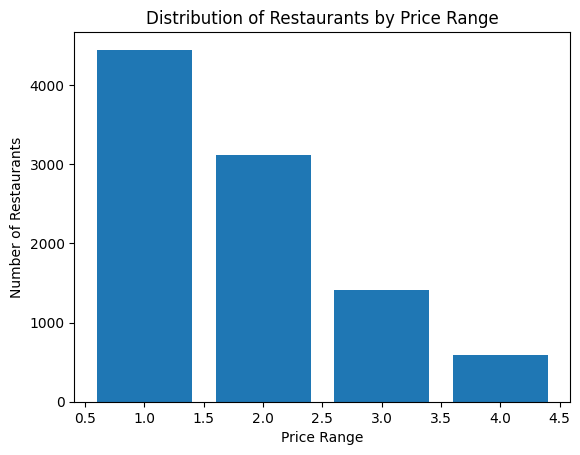

In [17]:
import matplotlib.pyplot as plt

plt.bar(price_counts.index, price_counts.values)

plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurants by Price Range")

plt.show()

In [18]:
delivery_counts = df["Has Online delivery"].value_counts()

delivery_counts

,count
Has Online delivery,
No,7100
Yes,2451


# **TASK 2**

In [19]:
delivery_percentage = (delivery_counts / len(df)) * 100

delivery_percentage.round(2)

,count
Has Online delivery,
No,74.34
Yes,25.66


In [20]:
delivery_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean()

delivery_rating.round(2)

,Aggregate rating
Has Online delivery,
No,2.47
Yes,3.25


In [21]:
rating_counts = df["Aggregate rating"].value_counts().sort_index()

rating_counts

,count
Aggregate rating,
0.0,2148
1.8,1
1.9,2
2.0,7
2.1,15
2.2,27
2.3,47
2.4,87
2.5,110


In [22]:
rating_counts.sort_values(ascending=False).head()

,count
Aggregate rating,
0.0,2148
3.2,522
3.1,519
3.4,498
3.3,483


In [23]:
average_votes = df["Votes"].mean()

average_votes

np.float64(156.909747670401)

In [24]:
cuisine_combinations = (
    df["Cuisines"]
    .dropna()
    .value_counts()
)

cuisine_combinations.head(10)

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Chinese,354
Fast Food,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


In [25]:
combination_ratings = (
    df.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

combination_ratings.head(10)

,Aggregate rating
Cuisines,
"Burger, Bar Food, Steak",4.9
"American, Burger, Grill",4.9
"American, Caribbean, Seafood",4.9
"American, Coffee and Tea",4.9
"Mexican, American, Healthy Food",4.9
"Italian, Bakery, Continental",4.9
"BBQ, Breakfast, Southern",4.9
"European, German",4.9
"Hawaiian, Seafood",4.9


In [26]:
df[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,9551.000000,9551.000000
mean,25.854381,64.126574
std,11.007935,41.467058
min,-41.330428,-157.948486
25%,28.478713,77.081343
50%,28.570469,77.191964
75%,28.642758,77.282006
max,55.976980,174.832089


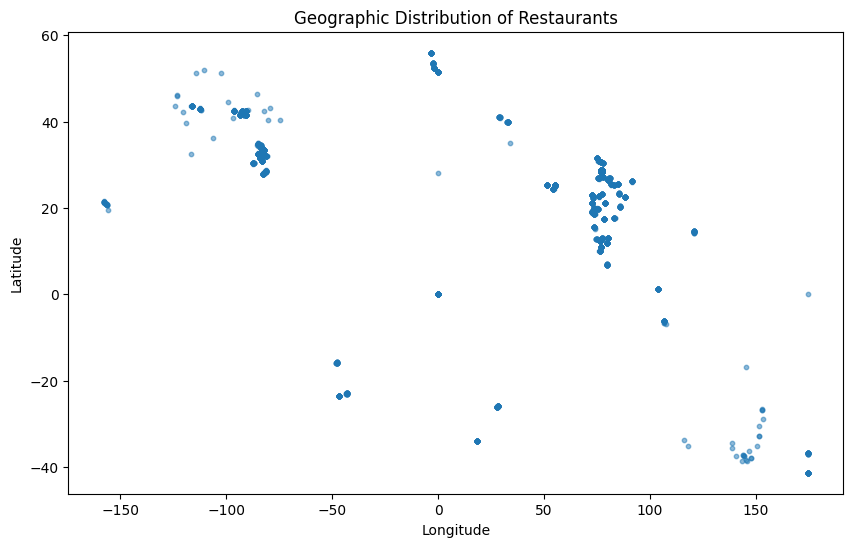

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    alpha=0.5,
    s=10
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Restaurants")

plt.show()

In [28]:
from sklearn.cluster import DBSCAN

coordinates = df[["Latitude", "Longitude"]]

dbscan = DBSCAN(eps=2, min_samples=5)
clusters = dbscan.fit_predict(coordinates)

df["Cluster"] = clusters

df["Cluster"].value_counts()

,count
Cluster,
15,7651
16,497
4,180
17,121
6,101
19,90
18,63
14,60
34,60


In [29]:
restaurant_counts = df['Restaurant Name'].value_counts()

restaurant_counts.head(20)

,count
Restaurant Name,
Cafe Coffee Day,83
Domino's Pizza,79
Subway,63
Green Chick Chop,51
McDonald's,48
Keventers,34
Pizza Hut,30
Giani,29
Baskin Robbins,28


In [30]:
chain_analysis = df.groupby('Restaurant Name').agg(
    Average_Rating=('Aggregate rating', 'mean'),
    Total_Votes=('Votes', 'sum'),
    Number_of_Restaurants=('Restaurant ID', 'count')
)

chain_analysis = chain_analysis[chain_analysis['Number_of_Restaurants'] > 1]

chain_analysis.sort_values('Total_Votes', ascending=False).head(10)

,Average_Rating,Total_Votes,Number_of_Restaurants
Restaurant Name,,,
Barbeque Nation,4.353846,28142,26
AB's - Absolute Barbecues,4.825000,13400,4
Big Chill,4.475000,10853,4
Farzi Cafe,4.366667,10098,6
Truffles,3.950000,9682,2
Chili's,4.580000,8156,5
Joey's Pizza,4.250000,7807,2
Big Yellow Door,4.266667,7511,3
Saravana Bhavan,4.133333,7238,3


# **TASK 3**

In [31]:
df['Rating text'].value_counts()

,count
Rating text,
Average,3737
Not rated,2148
Good,2100
Very Good,1079
Excellent,301
Poor,186


In [32]:
df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


In [33]:
review_columns = [col for col in df.columns if 'review' in col.lower()]

review_columns

[]

In [34]:
rating_text_counts = df['Rating text'].value_counts()

rating_text_counts

,count
Rating text,
Average,3737
Not rated,2148
Good,2100
Very Good,1079
Excellent,301
Poor,186


In [35]:
positive_ratings = ['Good', 'Very Good', 'Excellent']
negative_ratings = ['Poor']

positive_count = df[df['Rating text'].isin(positive_ratings)].shape[0]
negative_count = df[df['Rating text'].isin(negative_ratings)].shape[0]

print("Positive ratings:", positive_count)
print("Negative ratings:", negative_count)

Positive ratings: 3480
Negative ratings: 186


In [37]:
neutral_count = df[df['Rating text'] == 'Average'].shape[0]
not_rated_count = df[df['Rating text'] == 'Not rated'].shape[0]

print("Neutral ratings:", neutral_count)
print("Not rated:", not_rated_count)

Neutral ratings: 3737
Not rated: 2148


In [38]:
if len(review_columns) == 0:
    print("Review length cannot be calculated because no review text column is available.")
    print("Therefore, the relationship between review length and rating cannot be analyzed.")

Review length cannot be calculated because no review text column is available.
Therefore, the relationship between review length and rating cannot be analyzed.


In [39]:
highest_votes = df.loc[df['Votes'].idxmax(), ['Restaurant Name', 'Votes']]
lowest_votes = df.loc[df['Votes'].idxmin(), ['Restaurant Name', 'Votes']]

print("Restaurant with highest votes:")
print(highest_votes)

print("\nRestaurant with lowest votes:")
print(lowest_votes)

Restaurant with highest votes:
Restaurant Name     Toit
Votes              10934
Name: 728, dtype: object

Restaurant with lowest votes:
Restaurant Name    Cantinho da Gula
Votes                             0
Name: 69, dtype: object


In [40]:
correlation = df['Votes'].corr(df['Aggregate rating'])

print("Correlation between Votes and Aggregate Rating:", correlation)

Correlation between Votes and Aggregate Rating: 0.31369058419541157


In [41]:
price_delivery = pd.crosstab(
    df['Price range'],
    df['Has Online delivery'],
    normalize='index'
) * 100

price_delivery.round(2)

Has Online delivery,No,Yes
Price range,,
1,84.23,15.77
2,58.69,41.31
3,70.81,29.19
4,90.96,9.04


In [42]:
price_booking = pd.crosstab(
    df['Price range'],
    df['Has Table booking'],
    normalize='index'
) * 100

price_booking.round(2)

Has Table booking,No,Yes
Price range,,
1,99.98,0.02
2,92.32,7.68
3,54.26,45.74
4,53.24,46.76


In [43]:
service_comparison = pd.DataFrame({
    'Online Delivery (%)': price_delivery['Yes'],
    'Table Booking (%)': price_booking['Yes']
})

service_comparison.round(2)

,Online Delivery (%),Table Booking (%)
Price range,,
1,15.77,0.02
2,41.31,7.68
3,29.19,45.74
4,9.04,46.76
